In [3]:
# Importing rqeuired libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Importing modules form sklearn library
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve

# Notebook formatting
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Importing harmless warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
# loading data
data = pd.read_csv('Accident_Information.csv')

In [5]:
# Sample data
data.head()

,Accident_Index,1st_Road_Class,1st_Road_Number,2nd_Road_Class,2nd_Road_Number,Accident_Severity,Carriageway_Hazards,Date,Day_of_Week,Did_Police_Officer_Attend_Scene_of_Accident,Junction_Control,Junction_Detail,Latitude,Light_Conditions,Local_Authority_(District),Local_Authority_(Highway),Location_Easting_OSGR,Location_Northing_OSGR,Longitude,LSOA_of_Accident_Location,Number_of_Casualties,Number_of_Vehicles,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Police_Force,Road_Surface_Conditions,Road_Type,Special_Conditions_at_Site,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Year,InScotland
0,200501BS00001,A,3218.0,NaN,0.0,Serious,NaN,2005-01-04,Tuesday,1.0,Data missing or out of range,Not at junction or within 20 metres,51.489096,Daylight,Kensington and Chelsea,Kensington and Chelsea,525680.0,178240.0,-0.191170,E01002849,1,1,0.0,1.0,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,17:42,Urban,Raining no high winds,2005,No
1,200501BS00002,B,450.0,C,0.0,Slight,NaN,2005-01-05,Wednesday,1.0,Auto traffic signal,Crossroads,51.520075,Darkness - lights lit,Kensington and Chelsea,Kensington and Chelsea,524170.0,181650.0,-0.211708,E01002909,1,1,0.0,5.0,Metropolitan Police,Dry,Dual carriageway,NaN,30.0,17:36,Urban,Fine no high winds,2005,No
2,200501BS00003,C,0.0,NaN,0.0,Slight,NaN,2005-01-06,Thursday,1.0,Data missing or out of range,Not at junction or within 20 metres,51.525301,Darkness - lights lit,Kensington and Chelsea,Kensington and Chelsea,524520.0,182240.0,-0.206458,E01002857,1,2,0.0,0.0,Metropolitan Police,Dry,Single carriageway,NaN,30.0,00:15,Urban,Fine no high winds,2005,No
3,200501BS00004,A,3220.0,NaN,0.0,Slight,NaN,2005-01-07,Friday,1.0,Data missing or out of range,Not at junction or within 20 metres,51.482442,Daylight,Kensington and Chelsea,Kensington and Chelsea,526900.0,177530.0,-0.173862,E01002840,1,1,0.0,0.0,Metropolitan Police,Dry,Single carriageway,NaN,30.0,10:35,Urban,Fine no high winds,2005,No
4,200501BS00005,Unclassified,0.0,NaN,0.0,Slight,NaN,2005-01-10,Monday,1.0,Data missing or out of range,Not at junction or within 20 metres,51.495752,Darkness - lighting unknown,Kensington and Chelsea,Kensington and Chelsea,528060.0,179040.0,-0.156618,E01002863,1,1,0.0,0.0,Metropolitan Police,Wet or damp,Single carriageway,NaN,30.0,21:13,Urban,Fine no high winds,2005,No


In [6]:
# Data shape
data.shape

(2047256, 34)

In [7]:
# Data validation and data cleaning
msg_data = pd.DataFrame({'Missing Values' : data.isnull().sum(), 'Data Types' : data.dtypes})

# Dataframe for first 2 columns
sample = data.head(2).T

# Concating msg_data with sample
sample = pd.concat([msg_data, sample], axis = 1)

# Renaming cols
sample.rename(columns = {0 : 'Sample_1', 1 : 'Sample_2'}, inplace = True)

# Sample
sample

,Missing Values,Data Types,Sample_1,Sample_2
Accident_Index,0,object,200501BS00001,200501BS00002
1st_Road_Class,0,object,A,B
1st_Road_Number,2,float64,3218.0,450.0
2nd_Road_Class,844272,object,NaN,C
2nd_Road_Number,17593,float64,0.0,0.0
Accident_Severity,0,object,Serious,Slight
Carriageway_Hazards,2007807,object,NaN,NaN
Date,0,object,2005-01-04,2005-01-05
Day_of_Week,0,object,Tuesday,Wednesday
Did_Police_Officer_Attend_Scene_of_Accident,278,float64,1.0,1.0


In [8]:
#No of  unique & missing values for target column
data['Accident_Severity'].value_counts(dropna = False)

Accident_Severity
Slight     1734548
Serious     286339
Fatal        26369
Name: count, dtype: int64

In [9]:
# Checking Row Duplicates
if len(data[data.duplicated(keep = False)]) > 0:
    print('Duplicate exists in row')
else:
    print('No duplicates in row')

No duplicates in row


In [10]:
# Checking Column Duplicates
import hashlib

def col_hash(series):
    return hashlib.md5(pd.util.hash_pandas_object(series, index=False).values).hexdigest()

hashed = data.apply(col_hash)
dups = hashed[hashed.duplicated()].index.tolist()
if len(dups)>0:
    print("Duplicate columns exists")
else:
    print('No duplicate columns exists')

No duplicate columns exists


In [11]:
# Data columns/features/dimensions
data.columns

Index(['Accident_Index', '1st_Road_Class', '1st_Road_Number', '2nd_Road_Class',
       '2nd_Road_Number', 'Accident_Severity', 'Carriageway_Hazards', 'Date',
       'Day_of_Week', 'Did_Police_Officer_Attend_Scene_of_Accident',
       'Junction_Control', 'Junction_Detail', 'Latitude', 'Light_Conditions',
       'Local_Authority_(District)', 'Local_Authority_(Highway)',
       'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude',
       'LSOA_of_Accident_Location', 'Number_of_Casualties',
       'Number_of_Vehicles', 'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Police_Force',
       'Road_Surface_Conditions', 'Road_Type', 'Special_Conditions_at_Site',
       'Speed_limit', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions',
       'Year', 'InScotland'],
      dtype='object')

In [12]:
# Checking Cat and Num Columns
num_cols = []
cat_cols = []
cat_cols = [col for col in data.columns if data[col].dtypes == 'O']
num_cols = [col for col in data.columns if data[col].dtypes != 'O']
print(f'Cat Cols: {cat_cols}, \n\nNum Cols: {num_cols}')

Cat Cols: ['Accident_Index', '1st_Road_Class', '2nd_Road_Class', 'Accident_Severity', 'Carriageway_Hazards', 'Date', 'Day_of_Week', 'Junction_Control', 'Junction_Detail', 'Light_Conditions', 'Local_Authority_(District)', 'Local_Authority_(Highway)', 'LSOA_of_Accident_Location', 'Police_Force', 'Road_Surface_Conditions', 'Road_Type', 'Special_Conditions_at_Site', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions', 'InScotland'], 

Num Cols: ['1st_Road_Number', '2nd_Road_Number', 'Did_Police_Officer_Attend_Scene_of_Accident', 'Latitude', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Speed_limit', 'Year']


In [13]:
# No of cat cols and num cols
print(f'Cat Cols: {len(cat_cols)} \nNum Cols: {len(num_cols)}')

Cat Cols: 21 
Num Cols: 13


In [14]:
# Converting object into category 
data[cat_cols] = data[cat_cols].astype('category')

In [15]:
# Checking the conversion
data.dtypes

Accident_Index                                 category
1st_Road_Class                                 category
1st_Road_Number                                 float64
2nd_Road_Class                                 category
2nd_Road_Number                                 float64
Accident_Severity                              category
Carriageway_Hazards                            category
Date                                           category
Day_of_Week                                    category
Did_Police_Officer_Attend_Scene_of_Accident     float64
Junction_Control                               category
Junction_Detail                                category
Latitude                                        float64
Light_Conditions                               category
Local_Authority_(District)                     category
Local_Authority_(Highway)                      category
Location_Easting_OSGR                           float64
Location_Northing_OSGR                          

In [16]:
# Checking cols with single unique value
unq_cols = data.columns[data.nunique(dropna=False) == 1].tolist()
if len(unq_cols) > 0:
    print(f'Single Value Unique Columns: {unq_cols}')
else:
    print('No single value unique cols exists')

No single value unique cols exists


In [17]:
# Checking cols with more than 30% data missing
mv_grt_30 = []
for col in data.columns:
    if data[col].isnull().mean()*100 > 30:
        mv_grt_30.append(col)
        
if len(mv_grt_30)>0:
    print(f'Cols with more than 30% missing values: {mv_grt_30}')
else:
    print('No cols with missing values greater than 30% exists')

Cols with more than 30% missing values: ['2nd_Road_Class', 'Carriageway_Hazards', 'Special_Conditions_at_Site']


In [18]:
# Creating data copy
data_subset = data.copy()

In [19]:
#List of non-important features to remive
rmv_list = ['1st_Road_Class', '1st_Road_Number', '2nd_Road_Class', '2nd_Road_Number', 'Junction_Control', 
           'Carriageway_Hazards', 'Junction_Detail', 'Local_Authority_(Highway)', 'Location_Easting_OSGR', 'Location_Northing_OSGR',
           'LSOA_of_Accident_Location', 'Police_Force', 'Special_Conditions_at_Site', 'InScotland']

#Consolidated list for removal
removal_list = list(set(rmv_list + mv_grt_30 + unq_cols))

#Count of the features to be removed
print('The no of features to remove:', len(removal_list))

#Count of columns before removing
print('The no of columns before removing:', data_subset.shape[1])

#Removing the features from the dataframe
data_subset.drop(columns=removal_list, inplace=True)

#Count of the features after removal
print('The no of columns after removal:', data_subset.shape[1])

The no of features to remove: 14
The no of columns before removing: 34
The no of columns after removal: 20


In [20]:
# Cat cols and num cols after 1st cleaning
num_cols = []
cat_cols = []
cat_cols = [col for col in data_subset.columns if data_subset[col].dtypes == 'category']
num_cols = [col for col in data_subset.columns if data_subset[col].dtypes != 'category']
print(f'Cat Cols: {cat_cols}, \n\nNum Cols: {num_cols}')

Cat Cols: ['Accident_Index', 'Accident_Severity', 'Date', 'Day_of_Week', 'Light_Conditions', 'Local_Authority_(District)', 'Road_Surface_Conditions', 'Road_Type', 'Time', 'Urban_or_Rural_Area', 'Weather_Conditions'], 

Num Cols: ['Did_Police_Officer_Attend_Scene_of_Accident', 'Latitude', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Speed_limit', 'Year']


In [21]:
# No of cat cols and num cols
print(f'Cat Cols: {len(cat_cols)} \nNum Cols: {len(num_cols)}')

Cat Cols: 11 
Num Cols: 9


In [22]:
# 2nd Data validation
msg_data = pd.DataFrame({'Missing Values' : data_subset.isnull().sum(), 'Data Types' : data_subset.dtypes})

# Dataframe for first 2 columns
sample = data_subset.head(2).T

# Concating msg_data with sample
sample = pd.concat([msg_data, sample], axis = 1)

# Renaming cols
sample.rename(columns = {0 : 'Sample_1', 1 : 'Sample_2'}, inplace = True)

# Sample
sample

,Missing Values,Data Types,Sample_1,Sample_2
Accident_Index,0,category,200501BS00001,200501BS00002
Accident_Severity,0,category,Serious,Slight
Date,0,category,2005-01-04,2005-01-05
Day_of_Week,0,category,Tuesday,Wednesday
Did_Police_Officer_Attend_Scene_of_Accident,278,float64,1.0,1.0
Latitude,174,float64,51.489096,51.520075
Light_Conditions,0,category,Daylight,Darkness - lights lit
Local_Authority_(District),0,category,Kensington and Chelsea,Kensington and Chelsea
Longitude,175,float64,-0.19117,-0.211708
Number_of_Casualties,0,int64,1,1


In [23]:
# Mode for category column
for col in cat_cols:
    if data_subset[col].isnull().sum() > 0:
        print(f"{col}: {data_subset[col].mode()[0]}")

Time: 17:00


In [24]:
# Imputing missing values in time col with mode
data_subset['Time'].fillna(data_subset['Time'].mode()[0], inplace=True)

In [25]:
# Median for Numerical column
for col in num_cols:
    if data_subset[col].isnull().sum() > 0:
        print(f"{col}: {data_subset[col].median()}")

Did_Police_Officer_Attend_Scene_of_Accident: 1.0
Latitude: 52.2375835
Longitude: -1.362233
Pedestrian_Crossing-Human_Control: 0.0
Pedestrian_Crossing-Physical_Facilities: 0.0
Speed_limit: 30.0


In [26]:
# Num cols to impute with mode
cols_to_remove = ['Latitude', 'Longitude']
cols_to_impute_with_mode = [c for c in num_cols if c not in cols_to_remove]
cols_to_impute_with_mode

['Did_Police_Officer_Attend_Scene_of_Accident',
 'Number_of_Casualties',
 'Number_of_Vehicles',
 'Pedestrian_Crossing-Human_Control',
 'Pedestrian_Crossing-Physical_Facilities',
 'Speed_limit',
 'Year']

In [27]:
# Imputing missing values in all num cols with mode except latitude & longitude
for col in cols_to_impute_with_mode:
    data_subset[col].fillna(data_subset[col].mode()[0], inplace=True)

In [28]:
# Drop only the rows where Latitude or Longitude is missing
data_subset = data_subset.dropna(subset=['Latitude', 'Longitude'])

In [29]:
# 3rd Data validation
msg_data = pd.DataFrame({'Missing Values' : data_subset.isnull().sum(), 'Data Types' : data_subset.dtypes})

# Dataframe for first 2 columns
sample = data_subset.head(2).T

# Concating msg_data with sample
sample = pd.concat([msg_data, sample], axis = 1)

# Renaming cols
sample.rename(columns = {0 : 'Sample_1', 1 : 'Sample_2'}, inplace = True)

# Sample
sample

,Missing Values,Data Types,Sample_1,Sample_2
Accident_Index,0,category,200501BS00001,200501BS00002
Accident_Severity,0,category,Serious,Slight
Date,0,category,2005-01-04,2005-01-05
Day_of_Week,0,category,Tuesday,Wednesday
Did_Police_Officer_Attend_Scene_of_Accident,0,float64,1.0,1.0
Latitude,0,float64,51.489096,51.520075
Light_Conditions,0,category,Daylight,Darkness - lights lit
Local_Authority_(District),0,category,Kensington and Chelsea,Kensington and Chelsea
Longitude,0,float64,-0.19117,-0.211708
Number_of_Casualties,0,int64,1,1


In [30]:
data_subset.shape

(2047081, 20)

# Observation 1

## Target Column Analysis

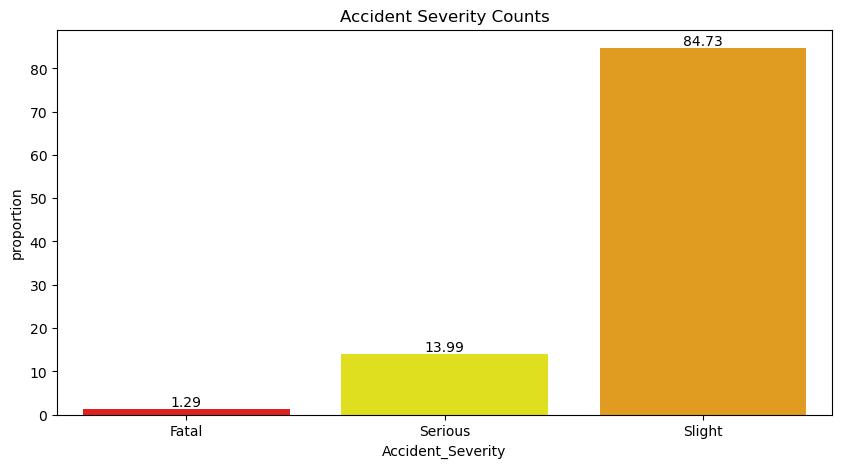

In [31]:
# Accident Severity analysis
plt.subplots(figsize = (10,5))
ax = sns.barplot(round(data_subset['Accident_Severity'].value_counts(normalize=True)*100, 2), palette = {'red', 'orange', 'yellow'})
[ax.bar_label(ax.containers[i]) for i in range(3)]
plt.title('Accident Severity Counts')
plt.show()

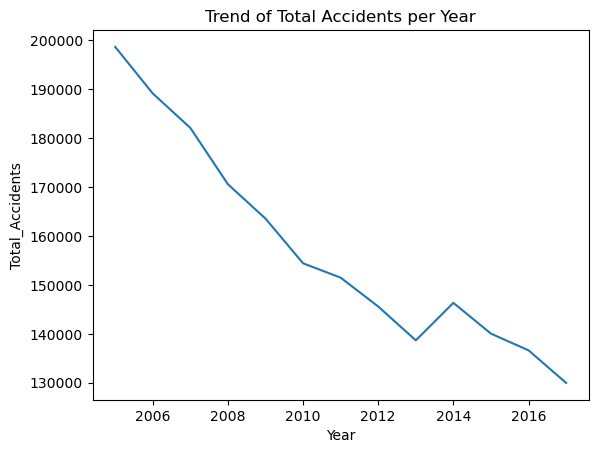

In [32]:
#1) What is the trend in the number of accidents over the years?

yearly_accidents = data_subset.groupby('Year').size().reset_index(name='Total_Accidents')
sns.lineplot(data=yearly_accidents, x='Year', y='Total_Accidents')
plt.title('Trend of Total Accidents per Year')
plt.show()

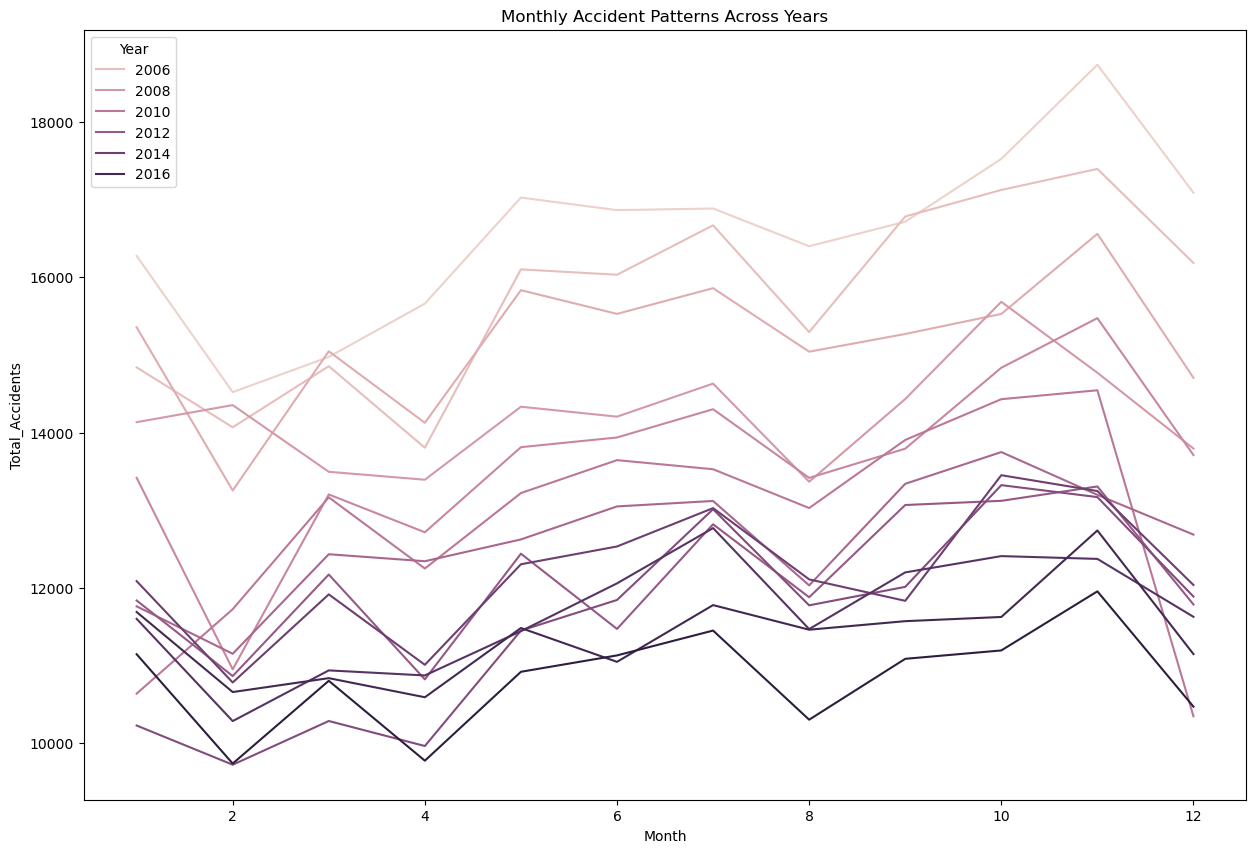

In [33]:
# Checking seasonal patterns

# Ensure Date column is datetime
data_subset['Date'] = pd.to_datetime(data_subset['Date'])

# Extract Year and Month
data_subset['Month'] = data_subset['Date'].dt.month

# Group by both Year and Month
monthly_trend = data_subset.groupby(['Year', 'Month']).size().reset_index(name='Total_Accidents')

# Plot
plt.subplots(figsize=(15,10))
sns.lineplot(data=monthly_trend, x='Month', y='Total_Accidents', hue='Year')
plt.title('Monthly Accident Patterns Across Years')
plt.show()

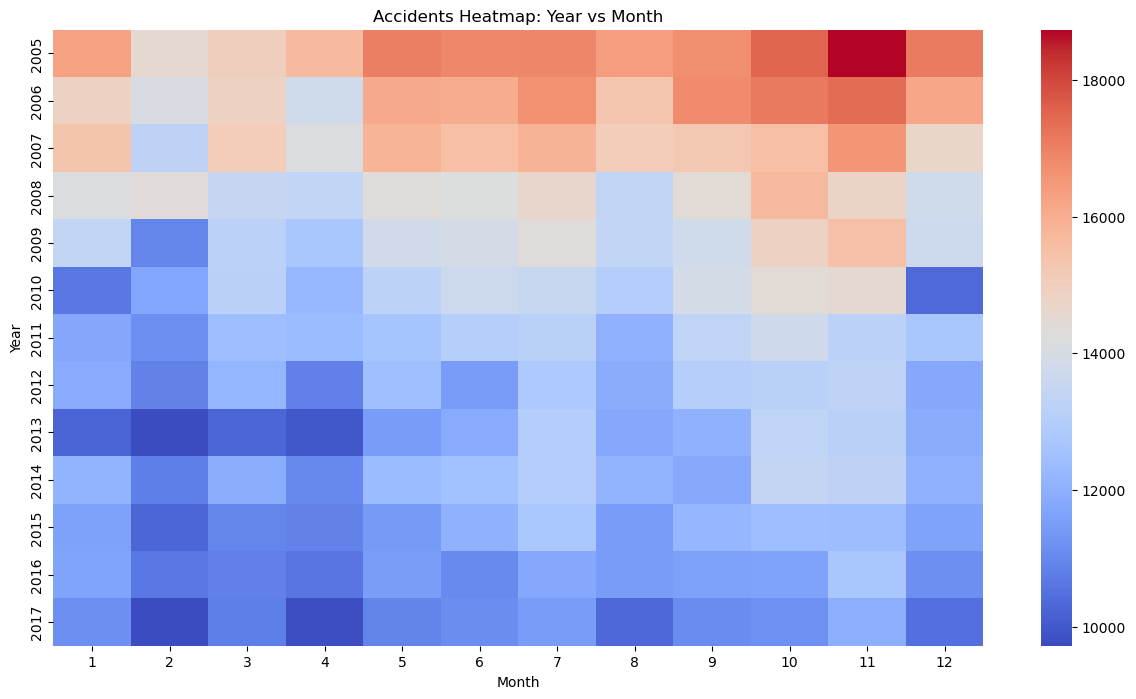

In [34]:
#Heatmap to find seasonal trends

# Converting the data into a table where: Rows = Years, Columns = Months, and Cells = Number of accidents
heat = data_subset.pivot_table(index='Year', columns='Month', values='Accident_Index', aggfunc='count')

# Plotting heatmap
plt.subplots(figsize=(15,8))
sns.heatmap(heat, annot=False, cmap='coolwarm')
plt.title('Accidents Heatmap: Year vs Month')
plt.show()

In [35]:
#2) Which local authority districts have the highest accident rates?

data['Local_Authority_(District)'].value_counts().head()

Local_Authority_(District)
Birmingham      39662
Leeds           27334
Westminster     19774
Glasgow City    18555
Bradford        18147
Name: count, dtype: int64

### What are their characteristics?

In [36]:
district_casualties = (
    data_subset.groupby('Local_Authority_(District)')['Number_of_Casualties']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
district_casualties

,Local_Authority_(District),Number_of_Casualties
0,Birmingham,54415
1,Leeds,37771
2,Bradford,26519
3,Liverpool,25763
4,Manchester,25010
5,Sheffield,23677
6,Glasgow City,23136
7,Westminster,22530
8,Kirklees,19635
9,"Edinburgh, City of",18711


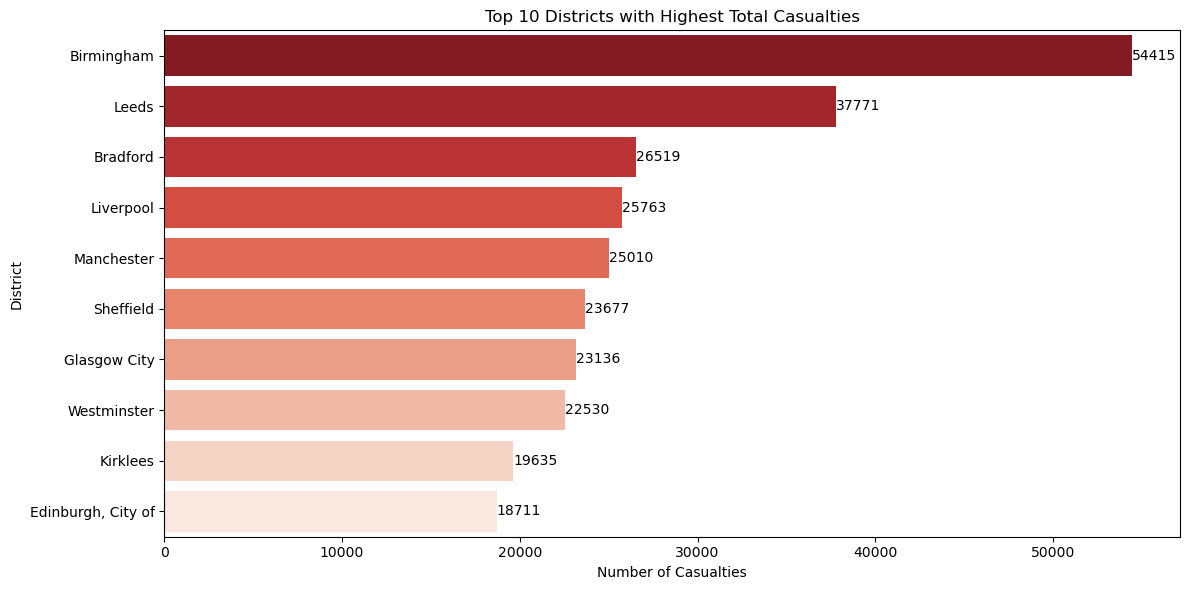

In [37]:
# Barplot for no of casualties v/s district

district_casualties['Local_Authority_(District)'] = district_casualties['Local_Authority_(District)'].astype(str)

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=district_casualties,
    x='Number_of_Casualties',
    y='Local_Authority_(District)',
    palette='Reds_r'
)

plt.xlabel('Number of Casualties')
plt.ylabel('District')
[ax.bar_label(ax.containers[i]) for i in range(10)]
ax.set_title('Top 10 Districts with Highest Total Casualties')
plt.tight_layout()
plt.show()

In [38]:
data_subset['Road_Type'].value_counts()

Road_Type
Single carriageway              1527757
Dual carriageway                 303384
Roundabout                       136743
One way street                    43256
Slip road                         21554
Unknown                           14387
Data missing or out of range          0
Name: count, dtype: int64

In [39]:
data_subset['Weather_Conditions'].value_counts()

Weather_Conditions
Fine no high winds              1639967
Raining no high winds            239254
Other                             44079
Unknown                           42513
Raining + high winds              28342
Fine + high winds                 25815
Snowing no high winds             13386
Fog or mist                       11066
Snowing + high winds               2485
Data missing or out of range        174
Name: count, dtype: int64

In [40]:
data_subset['Road_Surface_Conditions'].value_counts()

Road_Surface_Conditions
Dry                             1418099
Wet or damp                      568515
Frost or ice                      40318
Snow                              12164
Data missing or out of range       5141
Flood over 3cm. deep               2844
Name: count, dtype: int64

In [41]:
# How do weather conditions affect accident severity?

accident_weather = (data_subset.groupby('Accident_Severity')['Weather_Conditions'].value_counts().reset_index(name='Count'))
accident_weather

,Accident_Severity,Weather_Conditions,Count
0,Fatal,Fine no high winds,21818
1,Fatal,Raining no high winds,2540
2,Fatal,Fine + high winds,481
3,Fatal,Raining + high winds,400
4,Fatal,Other,398
5,Fatal,Unknown,364
6,Fatal,Fog or mist,238
7,Fatal,Snowing no high winds,110
8,Fatal,Snowing + high winds,15
9,Fatal,Data missing or out of range,5


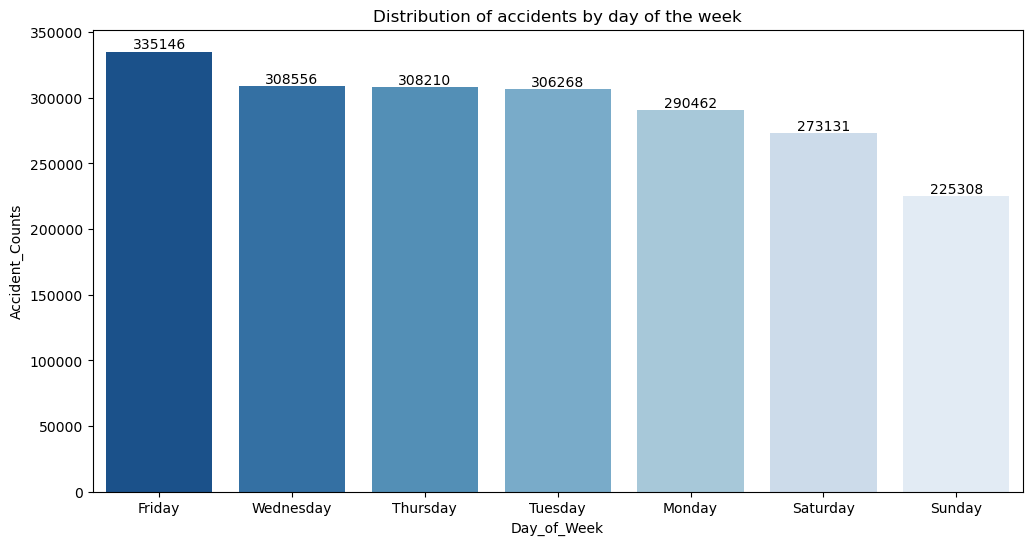

In [42]:
#3) What is the distribution of accidents by day of the week, and are there any patterns?

plt.figure(figsize=(12,6))
ax = sns.countplot(data = data_subset, x = 'Day_of_Week', order = data_subset['Day_of_Week'].value_counts().index, palette='Blues_r')
[ax.bar_label(ax.containers[i]) for i in range(7)]
plt.ylabel('Accident_Counts')
plt.title('Distribution of accidents by day of the week')
plt.show()

In [43]:
#4) Are certain road types associated with more severe accidents?

acc_severe_roads = data_subset.groupby('Accident_Severity')['Road_Type'].value_counts().reset_index(name = 'count')
acc_severe_roads

,Accident_Severity,Road_Type,count
0,Fatal,Single carriageway,20085
1,Fatal,Dual carriageway,5307
2,Fatal,Roundabout,421
3,Fatal,One way street,290
4,Fatal,Slip road,166
5,Fatal,Unknown,100
6,Fatal,Data missing or out of range,0
7,Serious,Single carriageway,226926
8,Serious,Dual carriageway,37532
9,Serious,Roundabout,12693


# ML Model

## Data Splitting

In [42]:
# Dependency Split

# Mapping target column
data_subset['Accident_Severity'] = data_subset['Accident_Severity'].map({'Fatal' : 3, 'Serious' : 2, 'Slight' : 1})

x = data_subset.drop(['Accident_Index', 'Accident_Severity'], axis = 1)
y = data_subset[['Accident_Severity']]

# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)

# Split Dimensions
print('Train Split Dimensions:', x_train.shape, y_train.shape)
print('Test Split Dimensions:', x_test.shape, y_test.shape)

Train Split Dimensions: (1432956, 19) (1432956, 1)
Test Split Dimensions: (614125, 19) (614125, 1)


## Label Encoding

In [43]:
#Label encoding

#Using categorical columns for encoding
cat_cols = [cols for cols in x_train.columns if x_train[cols].dtype == 'category']

#Label encoder
encoders = {}

#Apply label encoding on x_train columns
for col in cat_cols:
    encoders[col] = LabelEncoder()
    x_train[col] = encoders[col].fit_transform(x_train[col])

#Apply label encoding on x_test columns
for col in cat_cols:
    x_test[col] = encoders[col].transform(x_test[col])

## Hyper parameter tuning

In [92]:
# Model training
final_model = RandomForestClassifier(n_estimators = 200, max_features = 'log2', max_depth = 10, criterion = 'gini', bootstrap = True, random_state = 42)

final_model.fit(x_train, y_train)

# Training score
print('\nTraining Score:', round(final_model.score(x_train, y_train)*100, 2), '%')

# Predictions
y_pred = final_model.predict(x_test)

# Metrics
print('Testing Score:', round(accuracy_score(y_test, y_pred)*100, 2), '%')


Training Score: 84.72 %
Testing Score: 84.75 %


Classification Report:

               precision    recall  f1-score   support

           1       0.85      1.00      0.92    520458
           2       1.00      0.00      0.00     85785
           3       0.00      0.00      0.00      7882

    accuracy                           0.85    614125
   macro avg       0.62      0.33      0.31    614125
weighted avg       0.86      0.85      0.78    614125



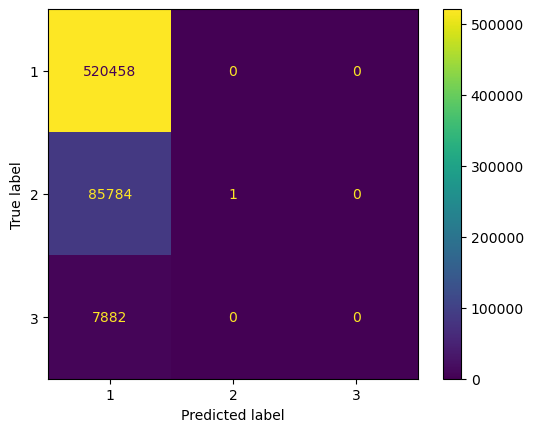

In [93]:
# Confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print('Classification Report:\n\n', classification_report(y_test, y_pred))

## 2nd version using Balanced RF and Stratification

In [44]:
# Using Stratification
x = data_subset.drop(['Accident_Index', 'Accident_Severity'], axis = 1)
y = data_subset[['Accident_Severity']]

# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42, stratify = y)

# Split Dimensions
print('Train Split Dimensions:', x_train.shape, y_train.shape)
print('Test Split Dimensions:', x_test.shape, y_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train Split Dimensions: (1432956, 19) (1432956, 1)
Test Split Dimensions: (614125, 19) (614125, 1)
Accident_Severity
1                    0.847256
2                    0.139863
3                    0.012881
Name: proportion, dtype: float64
Accident_Severity
1                    0.847256
2                    0.139862
3                    0.012882
Name: proportion, dtype: float64


In [45]:
#Label encoding

#Using categorical columns for encoding
cat_cols = [cols for cols in x_train.columns if x_train[cols].dtype == 'category']

#Label encoder
encoders = {}

#Apply label encoding on x_train columns
for col in cat_cols:
    encoders[col] = LabelEncoder()
    x_train[col] = encoders[col].fit_transform(x_train[col])

#Apply label encoding on x_test columns
for col in cat_cols:
    x_test[col] = encoders[col].transform(x_test[col])

In [48]:
# Model training using Balanced Random Forest
balanced_rf = BalancedRandomForestClassifier(n_estimators = 200, max_features = 'log2', max_depth = 10, criterion = 'gini', random_state = 42)
balanced_rf.fit(x_train, y_train)

# Training score
print('\nTraining Score:', round(balanced_rf.score(x_train, y_train)*100, 2), '%')

# Predictions
y_pred = balanced_rf.predict(x_test)

# Metrics
print('Testing Score:', round(accuracy_score(y_test, y_pred)*100, 2), '%')


Training Score: 56.41 %
Testing Score: 56.09 %


Classification Report:

               precision    recall  f1-score   support

           1       0.91      0.61      0.73    520321
           2       0.21      0.27      0.23     85893
           3       0.03      0.66      0.07      7911

    accuracy                           0.56    614125
   macro avg       0.38      0.51      0.34    614125
weighted avg       0.80      0.56      0.65    614125



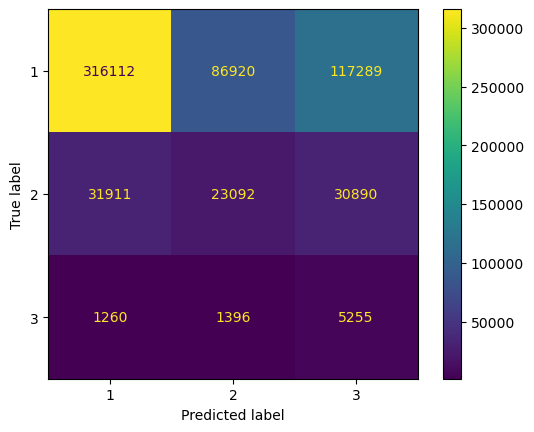

In [49]:
# Confusion Matrix
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print('Classification Report:\n\n', classification_report(y_test, y_pred))

In [50]:
# Finding feature importances from the final model
importances = balanced_rf.feature_importances_
importances

array([0.05136419, 0.01722971, 0.1269883 , 0.05218183, 0.03858495,
       0.03619529, 0.04665061, 0.07956085, 0.10575882, 0.00082297,
       0.01112184, 0.01132807, 0.02653572, 0.1585675 , 0.08274838,
       0.09436902, 0.01560437, 0.0234294 , 0.02095817])

In [51]:
# Index of the above array
indx = np.argsort(importances)
indx

array([ 9, 10, 11, 16,  1, 18, 17, 12,  5,  4,  6,  0,  3,  7, 14, 15,  8,
        2, 13], dtype=int64)

In [52]:
# Finding feature names
name_indx = list(x.columns)
name_indx

['Date',
 'Day_of_Week',
 'Did_Police_Officer_Attend_Scene_of_Accident',
 'Latitude',
 'Light_Conditions',
 'Local_Authority_(District)',
 'Longitude',
 'Number_of_Casualties',
 'Number_of_Vehicles',
 'Pedestrian_Crossing-Human_Control',
 'Pedestrian_Crossing-Physical_Facilities',
 'Road_Surface_Conditions',
 'Road_Type',
 'Speed_limit',
 'Time',
 'Urban_or_Rural_Area',
 'Weather_Conditions',
 'Year',
 'Month']

In [54]:
# Create DataFrame with Importances and Column Index
impurity_df = pd.DataFrame({
    'mean_impurity': importances,   # importance values from the model
    'column_index': indx            # indices of features sorted
})

# Map Column Index to Column Names
impurity_df['column_name'] = impurity_df['column_index'].apply(lambda x: name_indx[x])  # lambda function is used to map each index to its corresponding feature name    

# Select Only Relevant Columns
impurity_df = impurity_df[['column_name', 'mean_impurity']]  # keep only feature names and importance

# Sort Features by Importance (Descending)
impurity_df = impurity_df.sort_values(by='mean_impurity', ascending=False)  
# most important features appear at the top

# Reset Index
impurity_df = impurity_df.reset_index(drop=True)  # reset index after sorting to have sequential indices

# Calculate Percentage Importance
impurity_df['percentage_impurity'] = round(impurity_df['mean_impurity'] * 100, 3)  # convert importance to percentage and round to 3 decimals

# Calculate Cumulative Importance
impurity_df['cum_impurity'] = impurity_df['percentage_impurity'].cumsum()  # cumulative sum to see total contribution of top features

# Display the DataFrame
impurity_df

,column_name,mean_impurity,percentage_impurity,cum_impurity
0,Number_of_Casualties,0.158567,15.857,15.857
1,Road_Surface_Conditions,0.126988,12.699,28.556
2,Local_Authority_(District),0.105759,10.576,39.132
3,Urban_or_Rural_Area,0.094369,9.437,48.569
4,Time,0.082748,8.275,56.844
5,Road_Type,0.079561,7.956,64.800
6,Weather_Conditions,0.052182,5.218,70.018
7,Pedestrian_Crossing-Human_Control,0.051364,5.136,75.154
8,Year,0.046651,4.665,79.819
9,Day_of_Week,0.038585,3.858,83.677


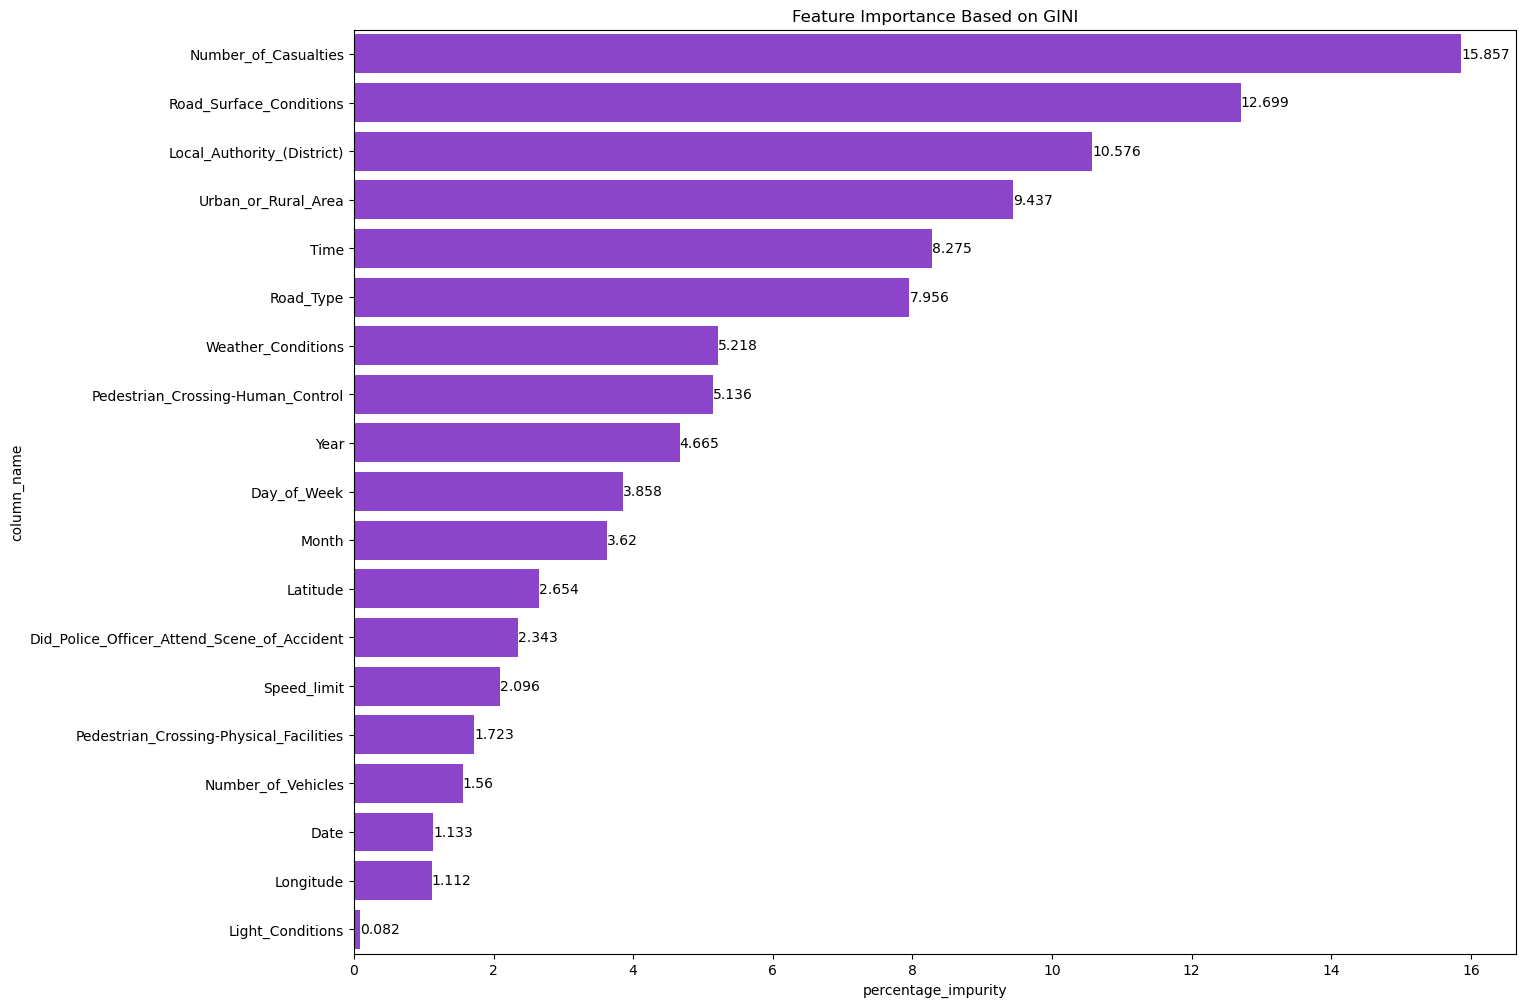

In [55]:
# Feature importance graph with horizontal bars
plt.figure(figsize=(15,12))
ax = sns.barplot(data = impurity_df, y = 'column_name', x = 'percentage_impurity', color='#8e2de2')
ax.bar_label(ax.containers[0])
plt.title('Feature Importance Based on GINI')
plt.show()

In [56]:
# Filtering the columns with 90% mean impurity
final_columns = list(impurity_df[impurity_df['cum_impurity'] <= 90].column_name)

# Filtering the x_train and x_test data for above columns
x_train_filtered = x_train[final_columns]
x_test_filtered = x_test[final_columns]

## 3rd version RF using imp features


Training Score: 55.42 %
Testing Score: 55.2 %
Classification Report:

               precision    recall  f1-score   support

           1       0.88      0.61      0.72    520321
           2       0.18      0.17      0.18     85893
           3       0.03      0.63      0.06      7911

    accuracy                           0.55    614125
   macro avg       0.36      0.47      0.32    614125
weighted avg       0.77      0.55      0.64    614125



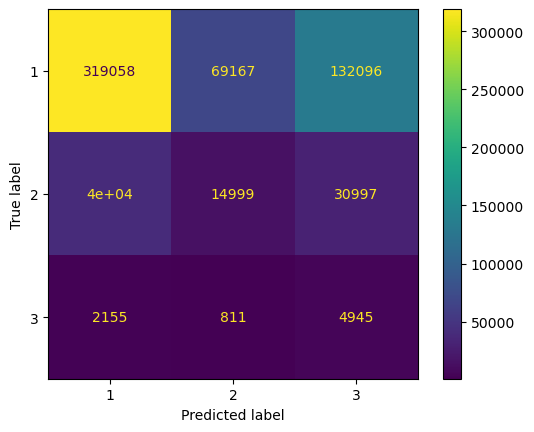

In [57]:
# Optimized model
op_balanced_rf = BalancedRandomForestClassifier(n_estimators = 200, max_features = 'log2', max_depth = 10, criterion = 'gini', random_state = 42)

# Training the data
op_balanced_rf.fit(x_train_filtered, y_train)

# Training score
print('\nTraining Score:', round(op_balanced_rf.score(x_train_filtered, y_train)*100, 2), '%')

# Predictions
opt_y_pred = op_balanced_rf.predict(x_test_filtered)

# Metrics
print('Testing Score:', round(accuracy_score(y_test, opt_y_pred)*100, 2), '%')
cm = ConfusionMatrixDisplay.from_predictions(y_test, opt_y_pred)
print('Classification Report:\n\n', classification_report(y_test, opt_y_pred))

## Proceeding with XGboost

In [44]:
# Data Splitting

# Mapping target column
data_subset['Accident_Severity'] = data_subset['Accident_Severity'].map({'Fatal' : 2, 'Serious' : 1, 'Slight' : 0})

x = data_subset.drop(['Accident_Index', 'Accident_Severity'], axis = 1)
y = data_subset['Accident_Severity']

# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.3, random_state = 42)

# Split Dimensions
print('Train Split Dimensions:', x_train.shape, y_train.shape)
print('Test Split Dimensions:', x_test.shape, y_test.shape)
print(sorted(y_train.unique()))
print(sorted(y_test.unique()))

Train Split Dimensions: (1432956, 19) (1432956,)
Test Split Dimensions: (614125, 19) (614125,)
[0, 1, 2]
[0, 1, 2]


In [45]:
#Label encoding

#Using categorical columns for encoding
cat_cols = [cols for cols in x_train.columns if x_train[cols].dtype == 'category']

#Label encoder
encoders = {}

#Apply label encoding on x_train columns
for col in cat_cols:
    encoders[col] = LabelEncoder()
    x_train[col] = encoders[col].fit_transform(x_train[col])

#Apply label encoding on x_test columns
for col in cat_cols:
    x_test[col] = encoders[col].transform(x_test[col])

## XGboost version 1 without weights

In [46]:
# Normal xgboost witgout weights

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)


Training Score: 84.75 %
Testing Score: 84.76 %
Classification Report:

               precision    recall  f1-score   support

           0       0.85      1.00      0.92    520458
           1       0.47      0.00      0.01     85785
           2       0.33      0.00      0.00      7882

    accuracy                           0.85    614125
   macro avg       0.55      0.33      0.31    614125
weighted avg       0.79      0.85      0.78    614125



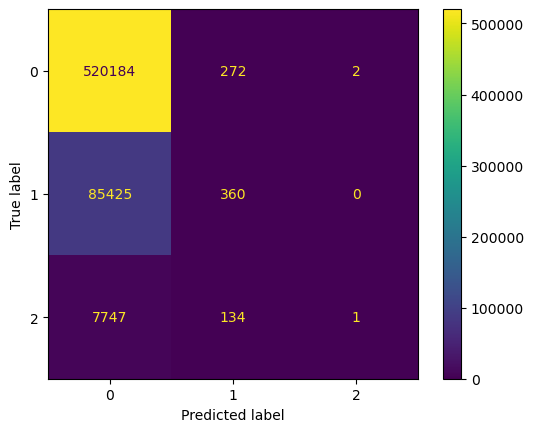

In [47]:
# Training score
print('\nTraining Score:', round(xgb_model.score(x_train, y_train)*100, 2), '%')

# Predictions
y_pred = xgb_model.predict(x_test)

# Metrics
print('Testing Score:', round(accuracy_score(y_test, y_pred)*100, 2), '%')
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print('Classification Report:\n\n', classification_report(y_test, y_pred))

## XGboost version 2 with weights

In [48]:
# Adding weights to the minority samples

counts = y_train.value_counts()
w0 = 1
w1 = counts[0] / counts[1]
w2 = counts[0] / counts[2]
print(w1, w2)

sample_weights = y_train.map({0:1, 1:w1, 2:w2})

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(x_train, y_train, sample_weight=sample_weights)

y_pred = xgb_model.predict(x_test)

6.053828699663383 65.66473738302591



Training Score: 56.53 %
Testing Score: 56.41 %
Classification Report:

               precision    recall  f1-score   support

           0       0.91      0.60      0.72    520458
           1       0.21      0.32      0.25     85785
           2       0.04      0.66      0.07      7882

    accuracy                           0.56    614125
   macro avg       0.38      0.53      0.35    614125
weighted avg       0.80      0.56      0.65    614125



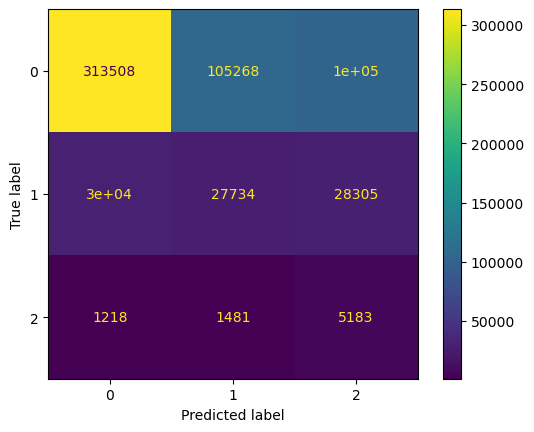

In [49]:
# Training score
print('\nTraining Score:', round(xgb_model.score(x_train, y_train)*100, 2), '%')

# Predictions
y_pred = xgb_model.predict(x_test)

# Metrics
print('Testing Score:', round(accuracy_score(y_test, y_pred)*100, 2), '%')
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
print('Classification Report:\n\n', classification_report(y_test, y_pred))

In [53]:
# Threshold tuning

# Get probabilities instead of labels
y_proba = xgb_model.predict_proba(x_test)

# Create new predictions with custom thresholds
fatal_thr = 0.20
ser_thr = 0.30

def tuned_predict(proba):
    preds = []
    for p in proba:
        if p[2] > fatal_thr:
            preds.append(2)
        elif p[1] > ser_thr:
            preds.append(1)
        else:
            preds.append(0)
    return np.array(preds)

y_pred_tuned = tuned_predict(y_proba)


Training Score: 56.53 %
Testing Score: 21.74 %
Classification Report:

               precision    recall  f1-score   support

           0       0.95      0.20      0.33    520458
           1       0.12      0.28      0.17     85785
           2       0.02      0.90      0.05      7882

    accuracy                           0.22    614125
   macro avg       0.36      0.46      0.18    614125
weighted avg       0.82      0.22      0.30    614125



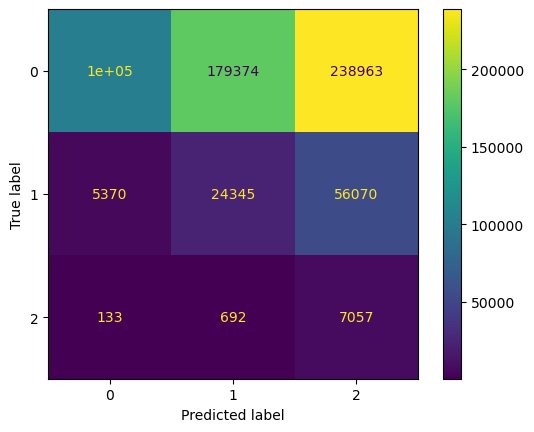

In [52]:
# Training score
print('\nTraining Score:', round(xgb_model.score(x_train, y_train)*100, 2), '%')

# Metrics
print('Testing Score:', round(accuracy_score(y_test, y_pred_tuned)*100, 2), '%')
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned)
print('Classification Report:\n\n', classification_report(y_test, y_pred_tuned))

In [54]:
# Balanced threshold tuning

y_proba_bd = xgb_model.predict_proba(x_test)

fatal_thr = 0.30
ser_thr = 0.35

def tuned_predict(proba):
    preds = []
    for p in proba:
        if p[2] > fatal_thr:     # class 2 → Fatal
            preds.append(2)
        elif p[1] > ser_thr:     # class 1 → Serious
            preds.append(1)
        else:
            preds.append(0)      # slight
    return np.array(preds)

y_pred_tuned_bd = tuned_predict(y_proba_bd)


Training Score: 56.53 %
Testing Score: 39.17 %
Classification Report:

               precision    recall  f1-score   support

           0       0.93      0.39      0.55    520458
           1       0.15      0.36      0.22     85785
           2       0.03      0.78      0.06      7882

    accuracy                           0.39    614125
   macro avg       0.37      0.51      0.28    614125
weighted avg       0.81      0.39      0.50    614125



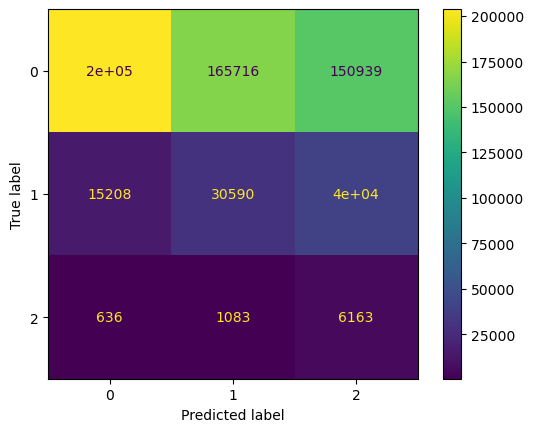

In [55]:
# Training score
print('\nTraining Score:', round(xgb_model.score(x_train, y_train)*100, 2), '%')

# Metrics
print('Testing Score:', round(accuracy_score(y_test, y_pred_tuned_bd)*100, 2), '%')
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned_bd)
print('Classification Report:\n\n', classification_report(y_test, y_pred_tuned_bd))